# Brownian motion

dichtheid, daarbij twee verschillende deeltjes en met zwaartekracht.
zwaartekracht nu weer ff uit, maar groot deeltje in een pool met kleine,
tracking van groot deeltje

diffusie, brownian motion

In [9]:
import numpy as np
import matplotlib.pyplot as plt


In [10]:
# Maken van de ParticleClass

class ParticleClass:
    # Het maken van het deeltje
    def __init__(self, m, v, r, R, c):
        self.m = m                         
        self.v = np.array(v, dtype=float)  
        self.r = np.array(r, dtype=float)  
        self.R = np.array(R, dtype=float)  
        self.c = c

    # Het updaten van de positie, eventueel met zwaartekracht
    def update_position(self):
        self.r += self.v * dt #+ 1/2 * a * dt**2  
    
#     # Het updaten van de snelheid door zwaartekracht
#     def update_velocity(self, a, dt):
#         self.v += a*dt
    
    # Harde wand
    def boxcollision(self):
        if abs(self.r[0]) + self.R > Box_length: 
            self.v[0] = -self.v[0]                                  # Omdraaien van de snelheid
            self.r[0] = np.sign(self.r[0]) * (Box_length - self.R)  # Zet terug net binnen box                 
        if abs(self.r[1]) + self.R > Box_length: 
            self.v[1] = -self.v[1]     
            self.r[1] = np.sign(self.r[1]) * (Box_length - self.R) 
            
    @property
    def momentum(self):
        return self.m * self.v
    
    @property
    def kin_energy(self):
        return 1/2 * self.m * np.dot(self.v, self.v)

In [11]:
# Aanmaken van de randvoorwaarden en initiele condities
Box_size_0 = 10
Box_length_0 = Box_size_0/2
Box_length = Box_length_0     # De grootte van de box kan wijzigen!

# Particles
particles = []
N = 40
v_0 = 1
a = np.array([0, -9])
#a = np.array([0, 0])

dt = 0.04

# tracken van het zware deeltje
track_x = []
track_y = []

# Aanmaken van deeltjes
for i in range(N-1):
    vx = np.random.uniform(-v_0,v_0)
    vy = np.random.choice([-1, 1])*np.sqrt(v_0**2-vx**2)        
    pos = Box_length_0*np.random.uniform(-1,1,2)
    particles.append(ParticleClass(m=1.0, v=[vx, vy], r = pos, R=.5,c='blue')) 

particles.append(ParticleClass(m=20.0, v=[0, 0], r = [0, 0], R=.5,c='red')) 


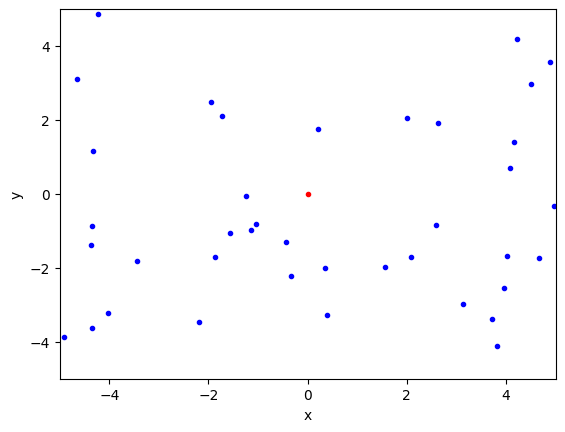

In [12]:
# Inspecteren van beginsituatie
plt.figure()

plt.xlabel('x')
plt.ylabel('y')

plt.xlim(-Box_length_0,Box_length_0)
plt.ylim(-Box_length_0,Box_length_0)


for particle, particle_object in enumerate(particles):
    plt.plot(particle_object.r[0],particle_object.r[1],color=particle_object.c,marker='.')
    # plt.arrow(particle_object.r[0],particle_object.r[1], 
    #           particle_object.v[0],particle_object.v[1], 
    #           head_width=0.05, head_length=0.1, color='red')
plt.show()


In [19]:
# Het bepalen of er een botsing plaats vindt
def collide_detection(self, other):
    dx = self.r[0] - other.r[0]
    dy = self.r[1] - other.r[1]
    rr = self.R + other.R
    return  dx**2+dy**2 < rr**2 
        
def particle_collision(p1: ParticleClass, p2: ParticleClass):
    """ past snelheden aan uitgaande van overlap """
    m1, m2 = p1.m, p2.m
    delta_r = p1.r - p2.r
    delta_v = p1.v - p2.v
    dot_product = np.dot(delta_r, delta_v)
    
    # Als deeltjes van elkaar weg bewegen dan geen botsing
    if dot_product >= 0: # '='-teken voorkomt ook problemen als delta_r == \vec{0}
        return
    
    distance_squared = np.dot(delta_r, delta_r) 
    # Botsing oplossen volgens elastische botsing in 2D
    p1.v -= 2 * m2 / (m1 + m2) * dot_product / distance_squared * delta_r
    p2.v += 2 * m1 / (m1 + m2) * dot_product / distance_squared * delta_r

def handle_collisions(particles):
    """ alle onderlinge botsingen afhandelen voor deeltjes in lijst """
    global counter
    num_particles = len(particles)
    for i in range(num_particles):
        for j in range(i+1, num_particles):
            if collide_detection(particles[i], particles[j]):
                particle_collision(particles[i], particles[j])
                counter += 1   # Toevoeging van volgende opdracht


In onderstaande code geven we de code voor de simulatie en volgen we de positie van het zware deeltje. 

```{exercise} Brownian motion in beeld
:label: ex-brownian-3
- Draai de onderstaande simulatie een keer en bestudeer de output.
- Voeg zelf een tweede tracking toe van een licht deeltje en verbeter de plot.
- Wat zijn overeenkomsten en verschillen tussen de beweging van de twee deeltjes?
- Wat valt je op als je de simulatie een aantal keer runt?
```

```{solution} ex-brownian-3
#jouw antwoord
```






In [ ]:
# tracken van het zware deeltje
track_x = []
track_y = []
num_col = []   #toegevoegd voor volgende opdracht



for i in range(400):
    counter = 0    
    for p in particles:
        p.update_position()    # Update positie        
        p.boxcollision()         # Wandbotsing werkt per deeltje
        
    handle_collisions(particles)
    
    track_x.append(particles[N-1].r[0])
    track_y.append(particles[N-1].r[1])
    num_col.append(counter)   # toegevoegd voor volgende opdracht



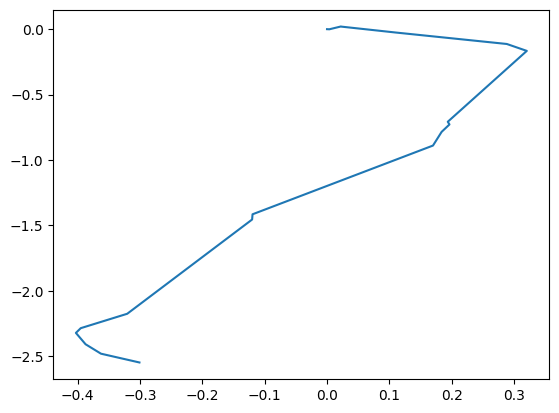

In [15]:
plt.figure()
plt.plot(track_x,track_y)
plt.show()

We zouden gevoel willen krijgen voor het aantal botsingen dat per tijdseenheid plaatsvinden. 
Elke keer dat er een botsing plaats vindt, zou de counter met 1 omhoog moeten gaan.
Idealiter wordt het aantal botsingen opgeslagen in een array zodat je het aantal botsingen als functie van de tijd kunt weergeven.

```{exercise}
Pas bovenstaand idee toe in de eerder gemaakte code.
Plot hieronder het aantal botsingen als functie van de tijd.
```


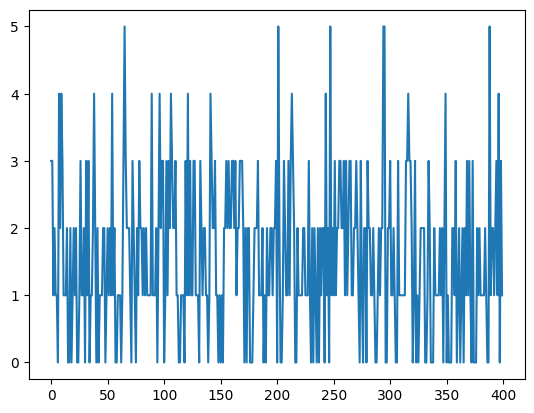

In [21]:
# Toelichting op jouw code
plt.figure()
plt.plot(num_col)
plt.show()


```{warning} 🌶 Let op!
:icon: false
De onderstaande opdrachten vallen buiten de stof maar telt mee als je excellent wilt behalen.
```

In zulke fysica modellen is de afgelegde weg van belang.
Deze afgelegde weg zegt iets over de snelheid van difussie. 

```{exercise} Afgelegde weg 🌶
:label: ex-brownian-4

Maak een histogram van de afgelegde weg voor alle deeltjes. 
Geef de afgelegde weg van het grote deeltje duidelijk aan.
```


In [8]:
# Jouw code

En nu we toch bezig zijn met twee verschillende deeltjes.... 

We kunnen twee "groepen" van deeltjes aanmaken, elk  met een andere massa. Als we dan de zwaartekracht aan zetten, dan zouden we verwachten dat de lichtere deeltjes boven komen "drijven".

```{exercise} Onderzoek dit vermoeden 🌶
```

In [ ]:
# Jouw code